In [116]:
import pandas as pd

df = pd.read_csv('../datasets/dirty_cafe_sales.csv')

df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


### Clean Data

In [117]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

for col in df:
    df[col] = df[col].replace(["UNKNOWN", "ERROR"], value=None)

df.dropna(inplace=True)
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
12,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03
...,...,...,...,...,...,...,...,...
9975,TXN_9668108,Cake,1.0,3.0,3.0,Cash,In-store,2023-01-20
9979,TXN_9933628,Smoothie,5.0,4.0,20.0,Cash,In-store,2023-07-20
9986,TXN_2858441,Sandwich,2.0,4.0,8.0,Credit Card,In-store,2023-12-14
9991,TXN_3897619,Sandwich,3.0,4.0,12.0,Cash,Takeaway,2023-02-24


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import torch
import numpy as np

# Categorical columns
to_encode = df[["Item", "Payment Method", "Location"]]
encoder = OneHotEncoder(sparse_output=False) # sparse false ensures it returns a dense numpy array
encoded = encoder.fit_transform(to_encode)

# Numerical columns
numerical = df[["Price Per Unit", "Total Spent"]].values

# Combine encoded + numerical features
X = np.hstack((encoded, numerical))
y = df["Quantity"]

# X = torch.tensor(X, dtype=torch.float32)
# y = torch.tensor(y.values, dtype=torch.float32)

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [121]:
import torch

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [122]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [123]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=15, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


In [124]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [125]:
train_losses = []
test_losses = []

epochs = 20

for epoch in range(epochs):
    
    #Training
    model.train()
    epoch_train_loss = 0
    
    for xb, yb in train_loader:
        preds = model(xb)
        loss = loss_fn(preds, yb)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        epoch_train_loss += loss.item()
        
    epoch_train_loss /= len(train_loader)   # calculate avg loss per batch
    train_losses.append(epoch_train_loss)
    
    #Testing
    model.eval()
    epoch_val_loss = 0
    
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            loss = loss_fn(preds, yb)
            epoch_val_loss += loss.item()
            
        epoch_val_loss /= len(test_loader)
        test_losses.append(epoch_val_loss)
        
    print(
        f"Epoch: {epoch:02d} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Test Loss: {epoch_val_loss:.4f}"
    )

Epoch: 00 | Train Loss: 7.9864 | Test Loss: 3.9240
Epoch: 01 | Train Loss: 2.0424 | Test Loss: 1.2092
Epoch: 02 | Train Loss: 1.0592 | Test Loss: 0.8086
Epoch: 03 | Train Loss: 0.7345 | Test Loss: 0.5947
Epoch: 04 | Train Loss: 0.5315 | Test Loss: 0.4597
Epoch: 05 | Train Loss: 0.4156 | Test Loss: 0.3796
Epoch: 06 | Train Loss: 0.3415 | Test Loss: 0.3256
Epoch: 07 | Train Loss: 0.2896 | Test Loss: 0.2797
Epoch: 08 | Train Loss: 0.2450 | Test Loss: 0.2341
Epoch: 09 | Train Loss: 0.2026 | Test Loss: 0.1849
Epoch: 10 | Train Loss: 0.1646 | Test Loss: 0.1530
Epoch: 11 | Train Loss: 0.1345 | Test Loss: 0.1264
Epoch: 12 | Train Loss: 0.1052 | Test Loss: 0.0944
Epoch: 13 | Train Loss: 0.0831 | Test Loss: 0.0809
Epoch: 14 | Train Loss: 0.0666 | Test Loss: 0.0637
Epoch: 15 | Train Loss: 0.0540 | Test Loss: 0.0537
Epoch: 16 | Train Loss: 0.0430 | Test Loss: 0.0428
Epoch: 17 | Train Loss: 0.0342 | Test Loss: 0.0335
Epoch: 18 | Train Loss: 0.0269 | Test Loss: 0.0297
Epoch: 19 | Train Loss: 0.0216 

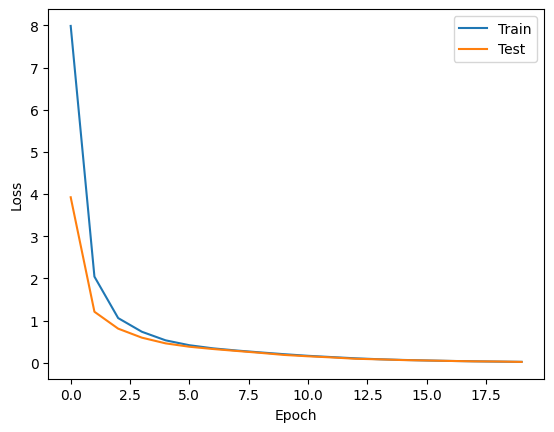

In [126]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()